In [ ]:
!pip install numpy

In [ ]:
pip install pandas matplotlib seaborn

In [ ]:
pip install scikit-learn

In [5]:
import sys
print(sys.executable)
print(sys.version)

C:\Users\v2126\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe
3.13.14 (tags/v3.13.14:fd17997, Jun 10 2026, 13:03:48) [MSC v.1944 64 bit (AMD64)]


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

SystemError: <built-in function acquire_lock> returned a result with an exception set

In [140]:
import zipfile

In [141]:
zip_path = "/content/drive/MyDrive/diabetes+130-us+hospitals+for+years+1999-2008.zip"

In [142]:
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extract("diabetic_data.csv", "/content/")

In [143]:
df=pd.read_csv("/content/diabetic_data.csv")

I chose the Diabetes 130-US Hospitals dataset because it is a real-world healthcare dataset with around 101,000 patient records and 50 features. It provides a multiclass classification problem where the Target is to predict hospital readmission. The dataset contains both numerical and categorical variables, missing values  which gives us scope for data preprocessing , data cleaning and feature engineering. It is also suitable for comparing different ensemble learning techniques such as Random Forest, Bagging, Gradient Boosting and XGBoost.

In [144]:
df.shape

(101766, 50)

There are 101766 rows and 50 columns

In [145]:
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [146]:
df.tail()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
101761,443847548,100162476,AfricanAmerican,Male,[70-80),?,1,3,7,3,...,No,Down,No,No,No,No,No,Ch,Yes,>30
101762,443847782,74694222,AfricanAmerican,Female,[80-90),?,1,4,5,5,...,No,Steady,No,No,No,No,No,No,Yes,NO
101763,443854148,41088789,Caucasian,Male,[70-80),?,1,1,7,1,...,No,Down,No,No,No,No,No,Ch,Yes,NO
101764,443857166,31693671,Caucasian,Female,[80-90),?,2,3,7,10,...,No,Up,No,No,No,No,No,Ch,Yes,NO
101765,443867222,175429310,Caucasian,Male,[70-80),?,1,1,7,6,...,No,No,No,No,No,No,No,No,No,NO


In [147]:
df.describe()

,encounter_id,patient_nbr,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,1.017660e+05,1.017660e+05,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,1.652016e+08,5.433040e+07,2.024006,3.715642,5.754437,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.422607
std,1.026403e+08,3.869636e+07,1.445403,5.280166,4.064081,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.933600
min,1.252200e+04,1.350000e+02,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,8.496119e+07,2.341322e+07,1.000000,1.000000,1.000000,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,1.523890e+08,4.550514e+07,1.000000,1.000000,7.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,2.302709e+08,8.754595e+07,3.000000,4.000000,7.000000,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,4.438672e+08,1.895026e+08,8.000000,28.000000,25.000000,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000


In [148]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

There are 13 integer columns and 37 object columns

In [149]:
df = df.replace("?", np.nan)

In [150]:
df.isnull().sum()

,0
encounter_id,0
patient_nbr,0
race,2273
gender,0
age,0
weight,98569
admission_type_id,0
discharge_disposition_id,0
admission_source_id,0
time_in_hospital,0


There are null values in weight,race,max_glu_serum,number_diagnoses,A1Cresult,payer_code,medical speciality,diag1,diag2,diag3

Data Cleaning

Removing columns which do not affect the target (readmitted) column

In [151]:
df = df.drop(columns=["encounter_id", "patient_nbr"])

In [152]:
df = df.drop(columns=["weight"])

In [153]:
df = df.drop(columns=["payer_code"])

In [154]:
df = df.drop(columns=['medical_specialty'])

In [155]:
df["A1Cresult"].value_counts(dropna=False)

,count
A1Cresult,
NaN,84748
>8,8216
Norm,4990
>7,3812


In [156]:
df["A1Cresult"] = df["A1Cresult"].fillna("Not_Measured")

In [157]:
df["max_glu_serum"].value_counts(dropna=False)

,count
max_glu_serum,
NaN,96420
Norm,2597
>200,1485
>300,1264


In [158]:
df["max_glu_serum"] = df["max_glu_serum"].fillna("Not_Measured")

In [159]:
df["race"] = df["race"].fillna("Unknown")

In [160]:
df["diag_1"] = df["diag_1"].fillna("Unknown")
df["diag_2"] = df["diag_2"].fillna("Unknown")
df["diag_3"] = df["diag_3"].fillna("Unknown")

In [161]:
df["gender"].value_counts(dropna=False)

,count
gender,
Female,54708
Male,47055
Unknown/Invalid,3


In [162]:
df["gender"] = df["gender"].replace("Unknown/Invalid", np.nan)

In [163]:
df["change"].value_counts()

,count
change,
No,54755
Ch,47011


In [164]:
df["medication_changed"] = df["change"].map({
    "No": 0,
    "Ch": 1
})

In [165]:
df["diabetesMed"].value_counts()

,count
diabetesMed,
Yes,78363
No,23403


In [166]:
df["diabetes_medication"] = df["diabetesMed"].map({
    "No": 0,
    "Yes": 1
})

In [167]:
print(df["examide"].value_counts())
print(df["citoglipton"].value_counts())

examide
No    101766
Name: count, dtype: int64
citoglipton
No    101766
Name: count, dtype: int64


In [168]:
df = df.drop(columns=["examide", "citoglipton"])

In [169]:
 df.duplicated().sum()

np.int64(0)

In [170]:
age_mapping = {
    '[0-10)': 5,
    '[10-20)': 15,
    '[20-30)': 25,
    '[30-40)': 35,
    '[40-50)': 45,
    '[50-60)': 55,
    '[60-70)': 65,
    '[70-80)': 75,
    '[80-90)': 85,
    '[90-100)': 95
}
df['age_numeric'] = df['age'].map(age_mapping)

EDA

UNIVARIATE ANALYSIS

Readmitted

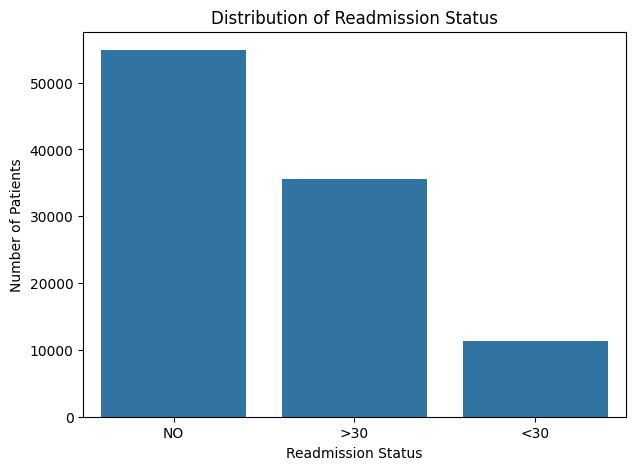

In [171]:
plt.figure(figsize=(7,5))

sns.countplot(data=df, x='readmitted')

plt.title("Distribution of Readmission Status")
plt.xlabel("Readmission Status")
plt.ylabel("Number of Patients")
plt.show()

CATEGORICAL COLUMNS

In [172]:
categorical_cols = df.select_dtypes(include='object').columns
print(categorical_cols)

Index(['race', 'gender', 'age', 'diag_1', 'diag_2', 'diag_3', 'max_glu_serum',
       'A1Cresult', 'metformin', 'repaglinide', 'nateglinide',
       'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide',
       'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose',
       'miglitol', 'troglitazone', 'tolazamide', 'insulin',
       'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted'],
      dtype='object')


GENDER

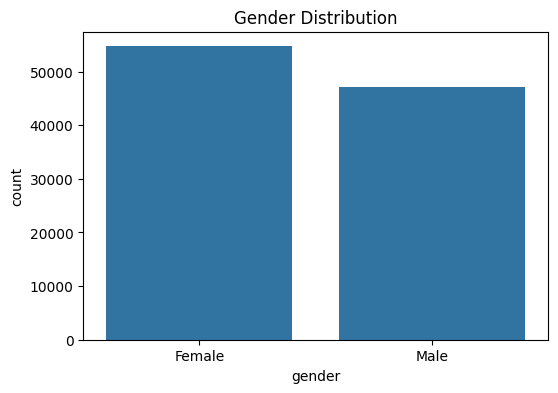

In [173]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='gender')
plt.title("Gender Distribution")
plt.show()

RACE DISTRIBUTION

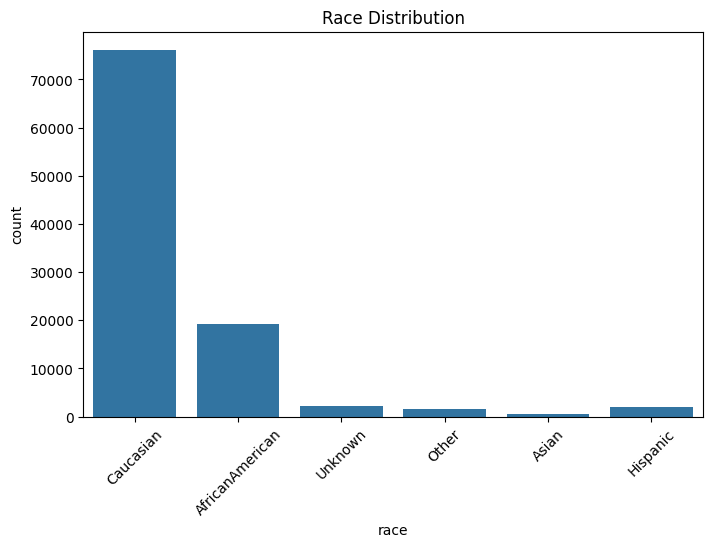

In [174]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='race')
plt.title("Race Distribution")
plt.xticks(rotation=45)
plt.show()

AGE GROUP DISTRIBUTION

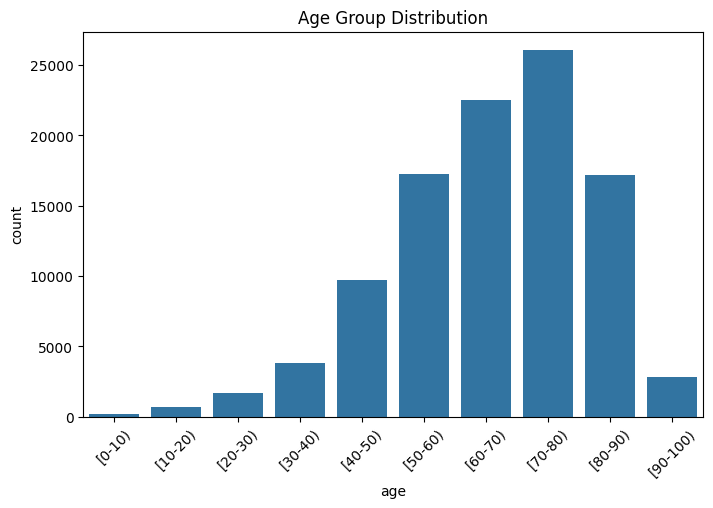

In [175]:
plt.figure(figsize=(8,5))
sns.countplot(
    data=df,
    x='age')
plt.title("Age Group Distribution")
plt.xticks(rotation=45)
plt.show()

INSULIN

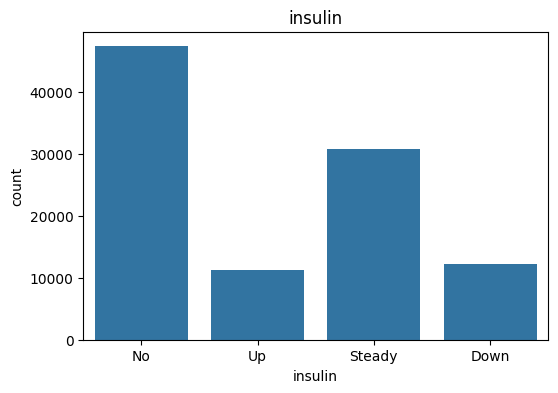

In [176]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='insulin')
plt.title("insulin")
plt.show()

NUMERICAL COLUMN

In [177]:
numeric_cols = df.select_dtypes(include=np.number).columns
print(numeric_cols)

Index(['admission_type_id', 'discharge_disposition_id', 'admission_source_id',
       'time_in_hospital', 'num_lab_procedures', 'num_procedures',
       'num_medications', 'number_outpatient', 'number_emergency',
       'number_inpatient', 'number_diagnoses', 'medication_changed',
       'diabetes_medication', 'age_numeric'],
      dtype='object')


TIME IN HOSPITAL

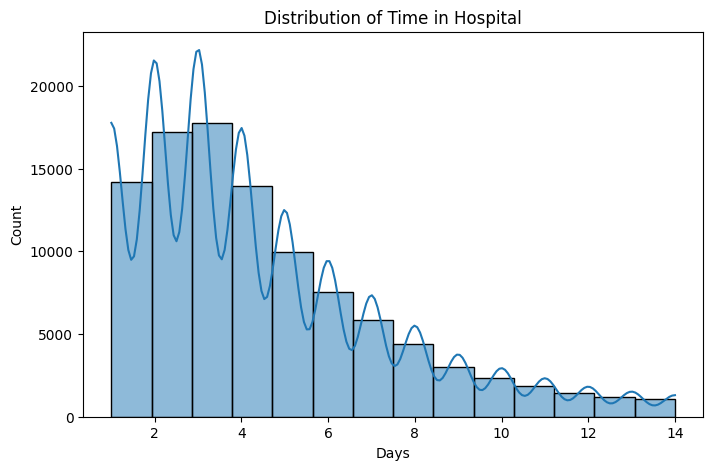

In [178]:
plt.figure(figsize=(8,5))
sns.histplot(df['time_in_hospital'], bins=14, kde=True)
plt.title("Distribution of Time in Hospital")
plt.xlabel("Days")
plt.show()

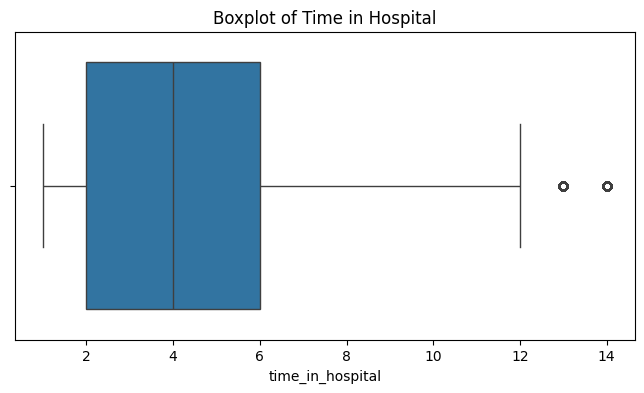

In [179]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df['time_in_hospital'])
plt.title("Boxplot of Time in Hospital")
plt.show()

NUMERICAL COLUMN

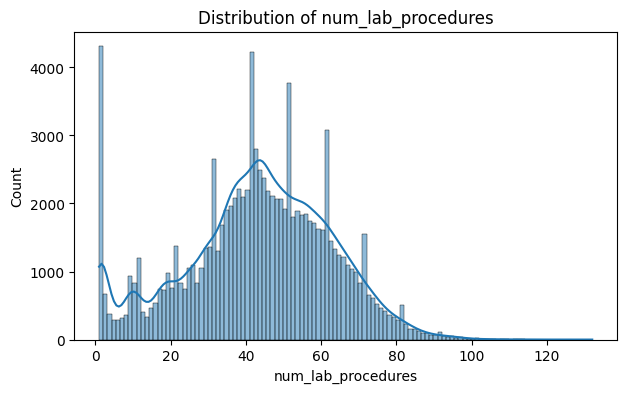

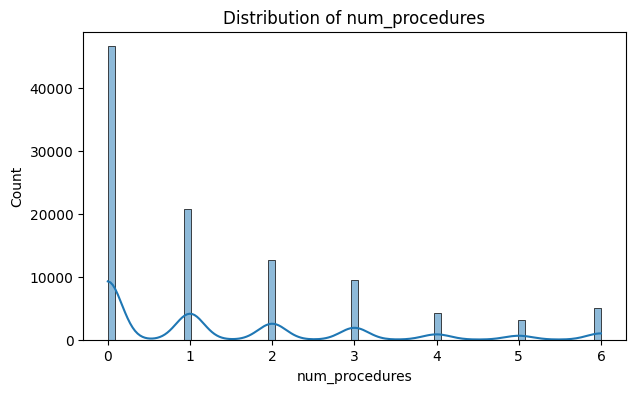

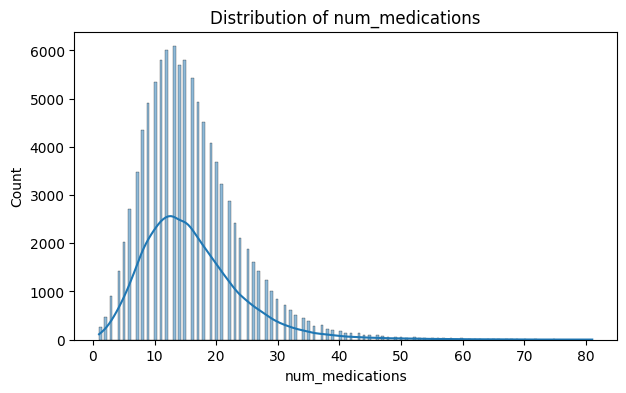

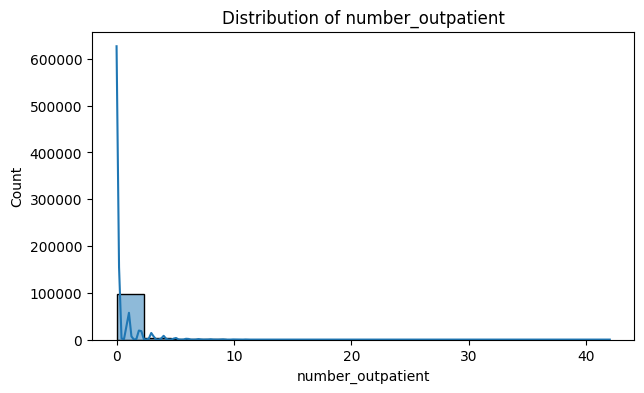

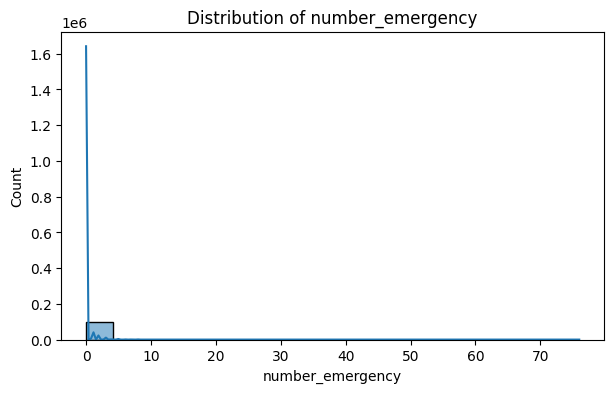

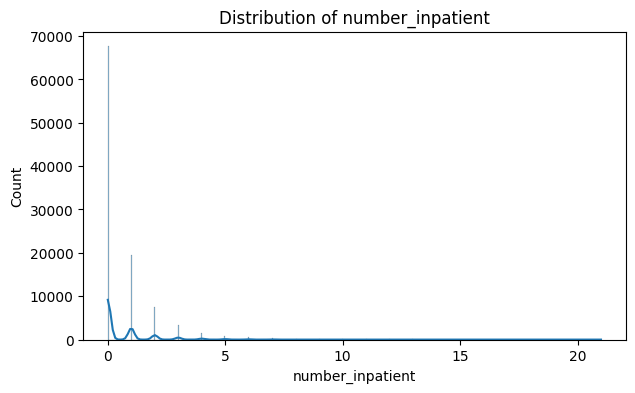

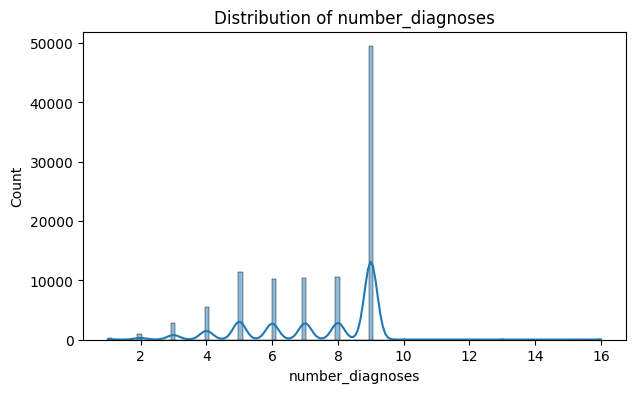

In [180]:
num_cols =[
    'num_lab_procedures',
    'num_procedures',
    'num_medications',
    'number_outpatient',
    'number_emergency',
    'number_inpatient',
    'number_diagnoses'
]

for col in num_cols:
    plt.figure(figsize=(7,4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

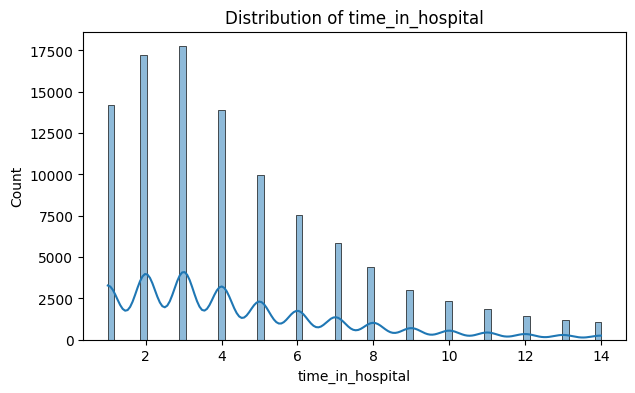

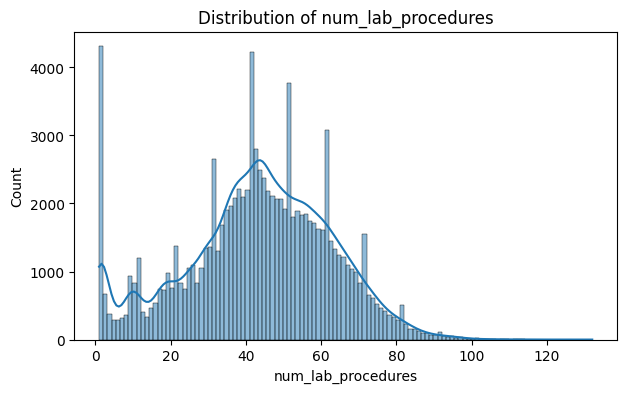

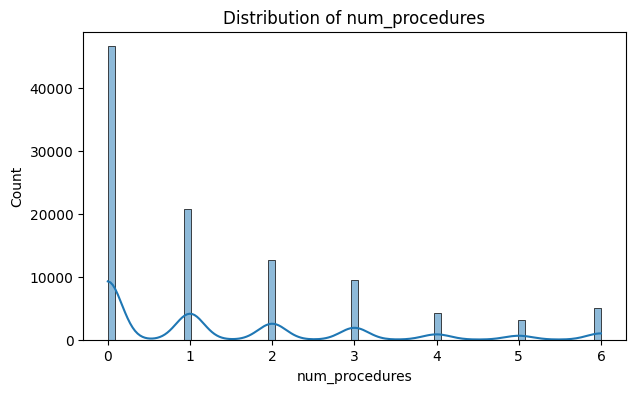

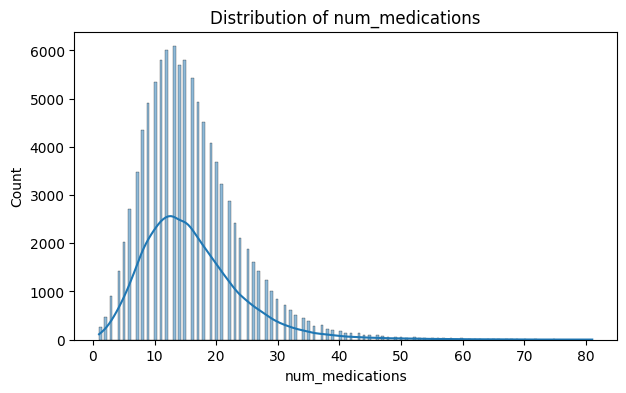

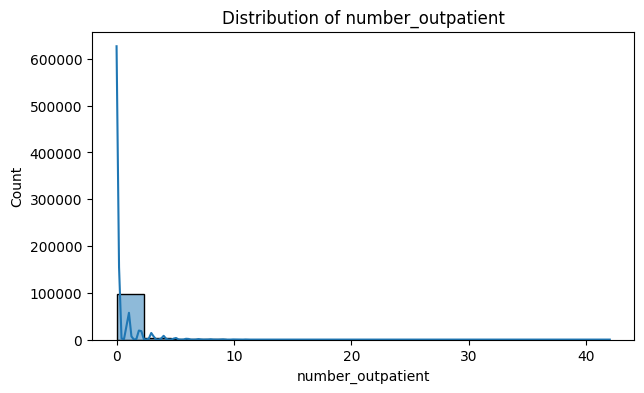

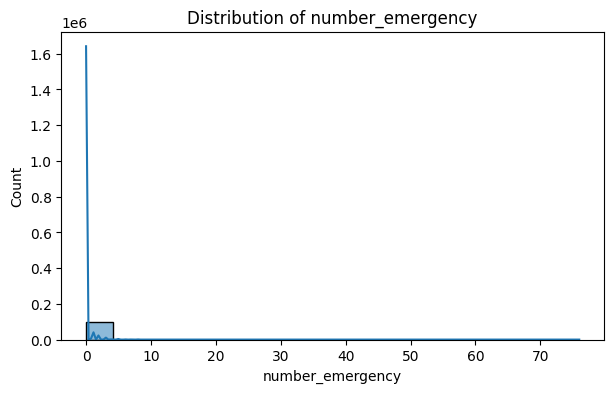

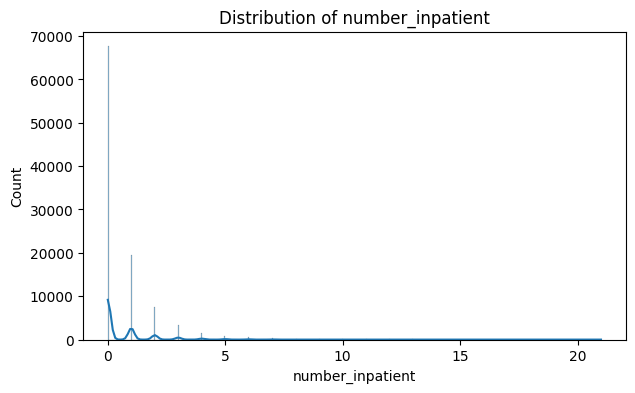

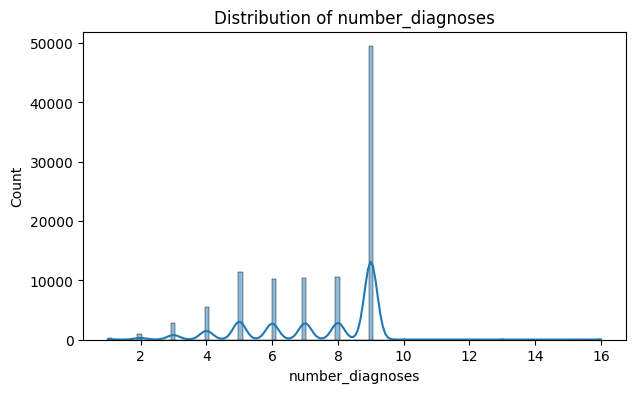

In [181]:
num_cols = [
    'time_in_hospital',
    'num_lab_procedures',
    'num_procedures',
    'num_medications',
    'number_outpatient',
    'number_emergency',
    'number_inpatient',
    'number_diagnoses'
]

for col in num_cols:
    plt.figure(figsize=(7,4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

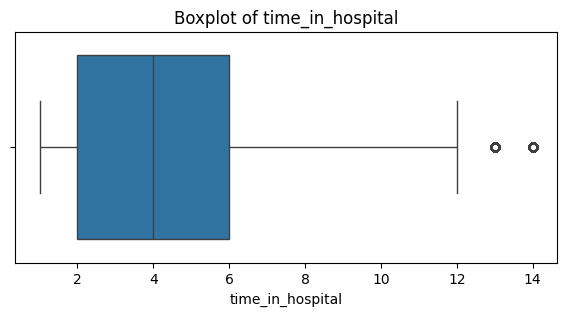

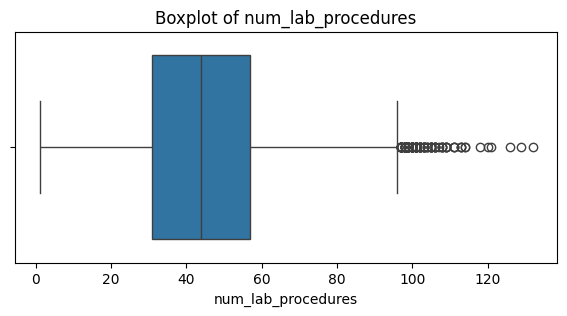

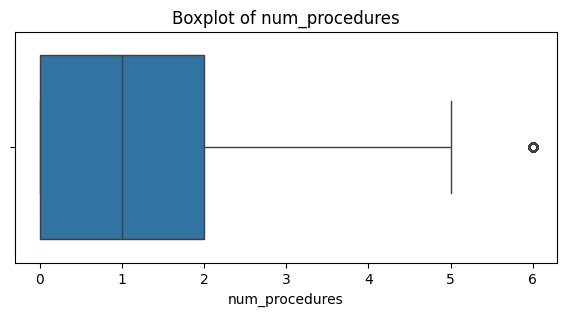

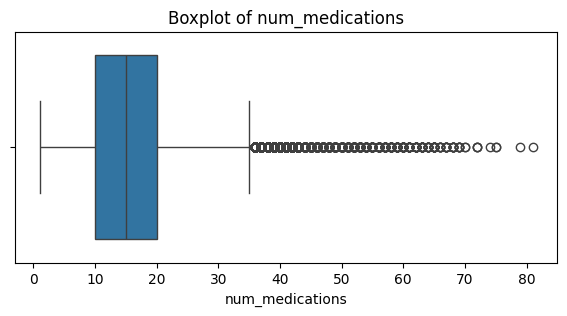

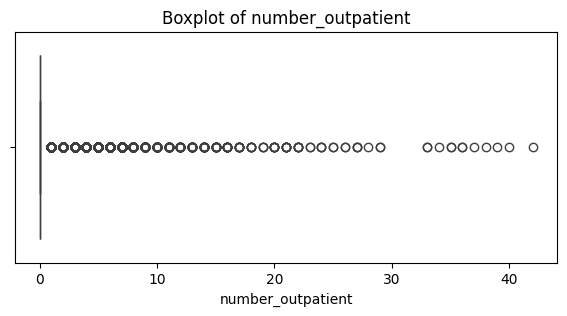

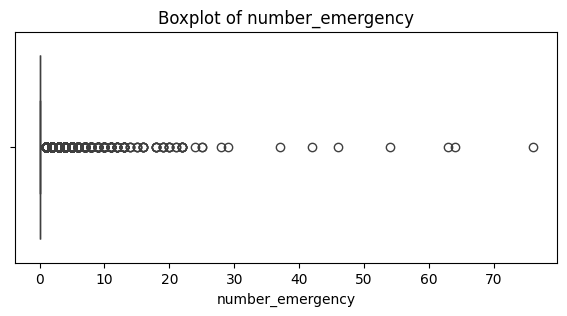

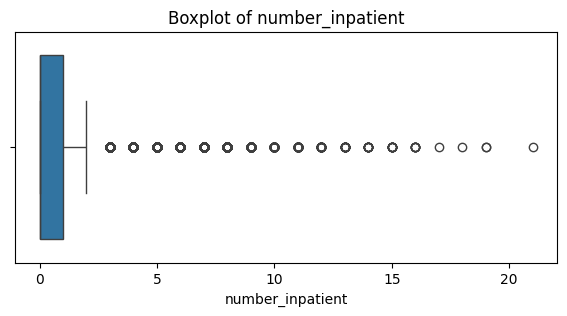

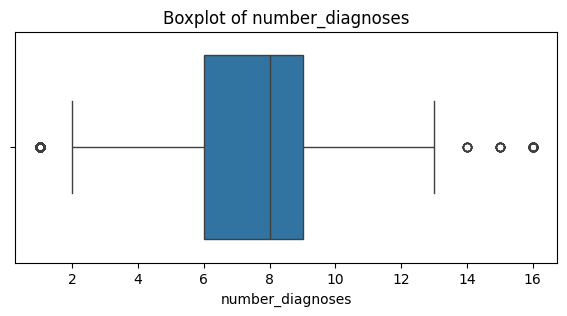

In [182]:
for col in num_cols:
    plt.figure(figsize=(7,3))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

BIVARIATE ANALYSIS

AGE VS READMISSION

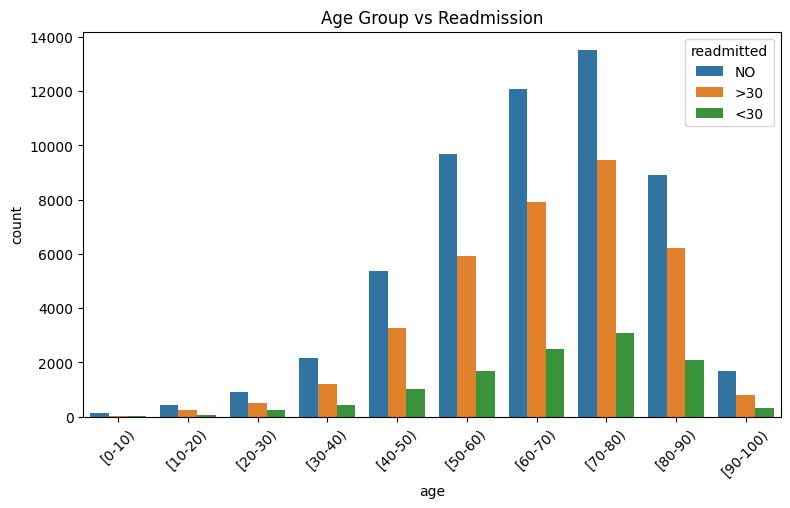

In [183]:
plt.figure(figsize=(9,5))
sns.countplot(
    data=df,
    x='age',
    hue='readmitted'
)
plt.title("Age Group vs Readmission")
plt.xticks(rotation=45)
plt.show()

GENDER VS READMISSION

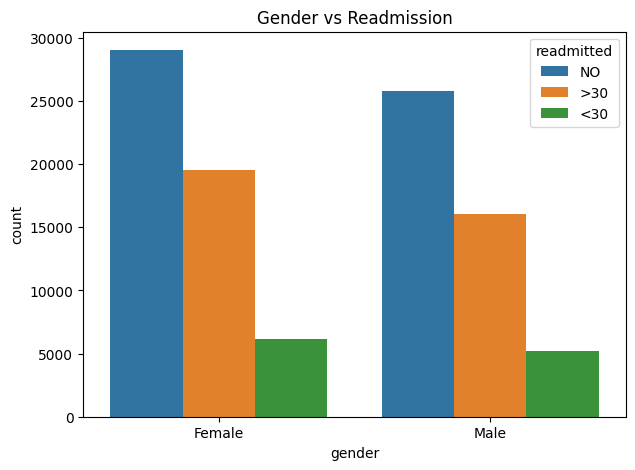

In [184]:
plt.figure(figsize=(7,5))
sns.countplot(
    data=df,
    x='gender',
    hue='readmitted'
)
plt.title("Gender vs Readmission")
plt.show()

TIME IN HOSPITAL VS READMISSION

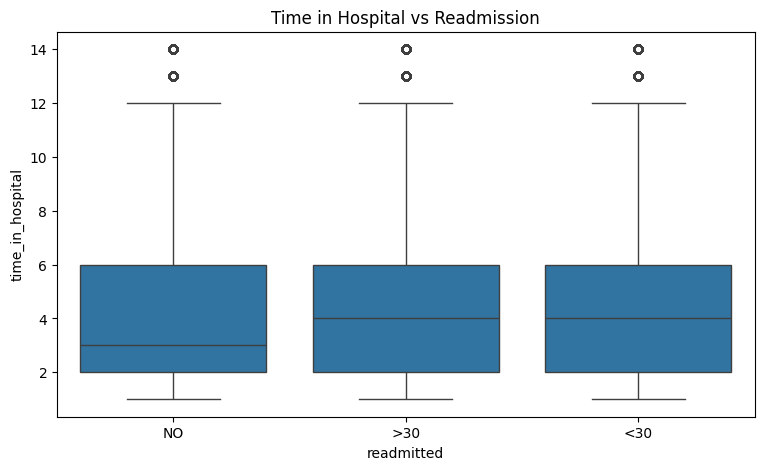

In [186]:
plt.figure(figsize=(9,5))
sns.boxplot(
    data=df,
    x='readmitted',
    y='time_in_hospital'
)
plt.title("Time in Hospital vs Readmission")
plt.show()

NUMBER OF MEDICATION VS READMISSION

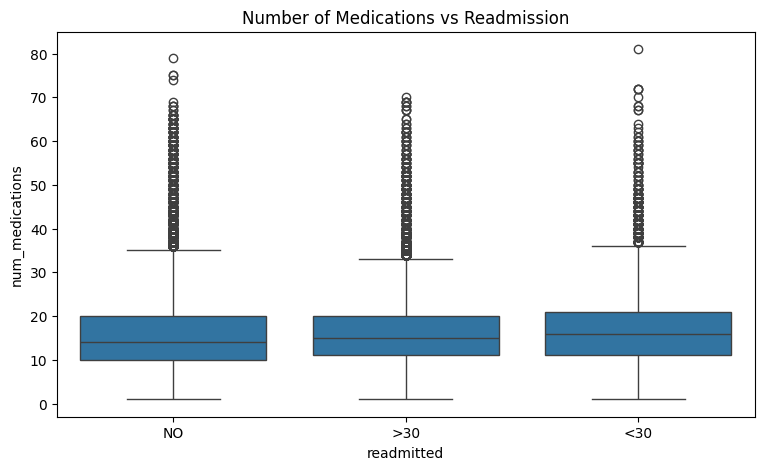

In [187]:
plt.figure(figsize=(9,5))
sns.boxplot(
    data=df,
    x='readmitted',
    y='num_medications'
)
plt.title("Number of Medications vs Readmission")
plt.show()

NUMBER OF INPATIENT VS READMISSION

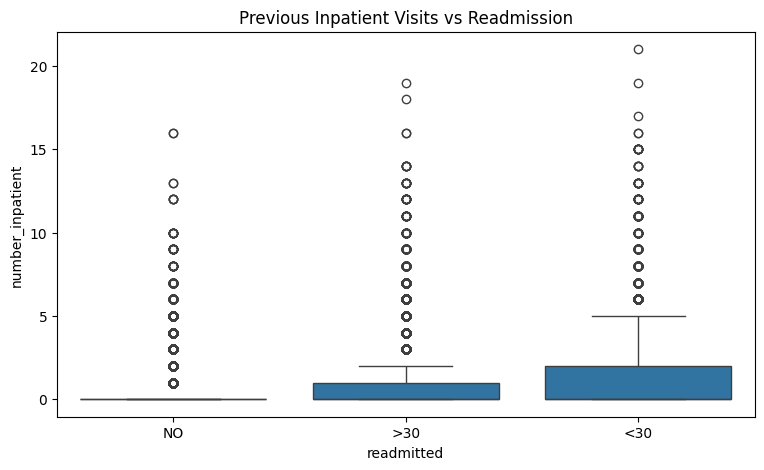

In [188]:
plt.figure(figsize=(9,5))
sns.boxplot(
    data=df,
    x='readmitted',
    y='number_inpatient'
)
plt.title("Previous Inpatient Visits vs Readmission")
plt.show()

NUMBER OF DIAGNOSES VS READMISSION

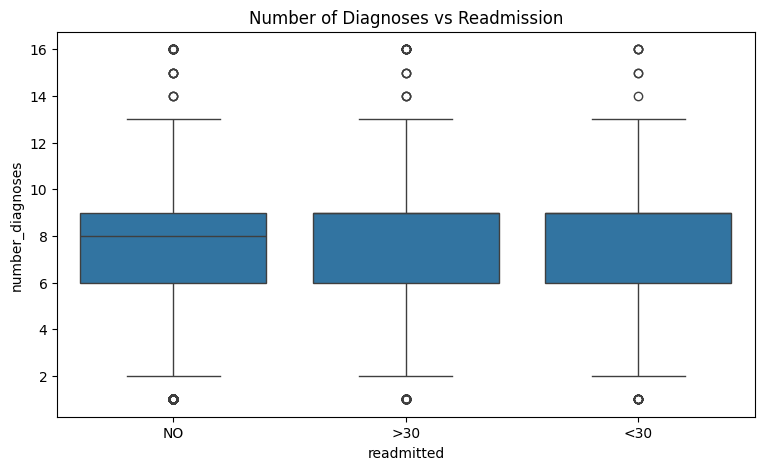

In [189]:
plt.figure(figsize=(9,5))
sns.boxplot(
    data=df,
    x='readmitted',
    y='number_diagnoses'
)

plt.title("Number of Diagnoses vs Readmission")
plt.show()

DIABETES MEDICATION VS READMISSION

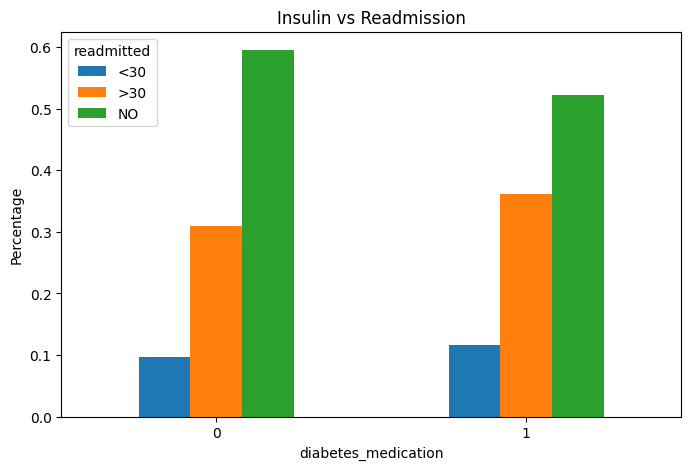

In [190]:
pd.crosstab(
    df['diabetes_medication'],
    df['readmitted'],
    normalize='index'
).plot(
    kind='bar',
    figsize=(8,5)
)
plt.ylabel("Percentage")
plt.title("Insulin vs Readmission")
plt.xticks(rotation=0)
plt.show()

INSULIN VS READMISSION

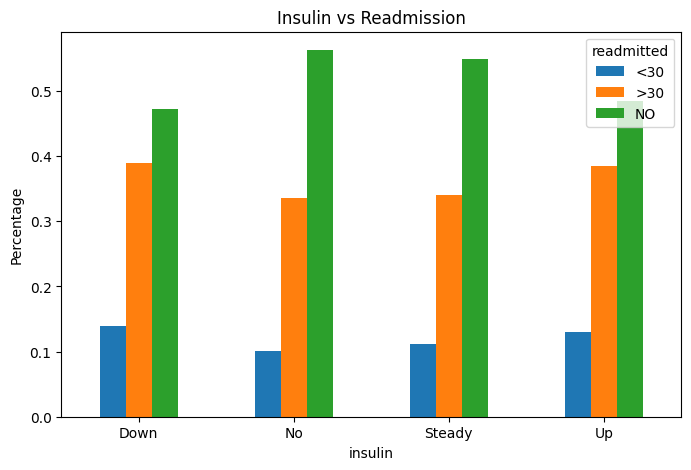

In [191]:
pd.crosstab(
    df['insulin'],
    df['readmitted'],
    normalize='index'
).plot(
    kind='bar',
    figsize=(8,5)
)
plt.ylabel("Percentage")
plt.title("Insulin vs Readmission")
plt.xticks(rotation=0)
plt.show()

AICRESULT VS READMISSION

In [192]:
pd.crosstab(
    df['A1Cresult'],
    df['readmitted'],
    normalize='index'
) * 100

readmitted,<30,>30,NO
A1Cresult,,,
>7,10.047219,34.102833,55.849948
>8,9.870983,35.309153,54.819864
Norm,9.659319,32.044088,58.296593
Not_Measured,11.423278,35.098173,53.478548


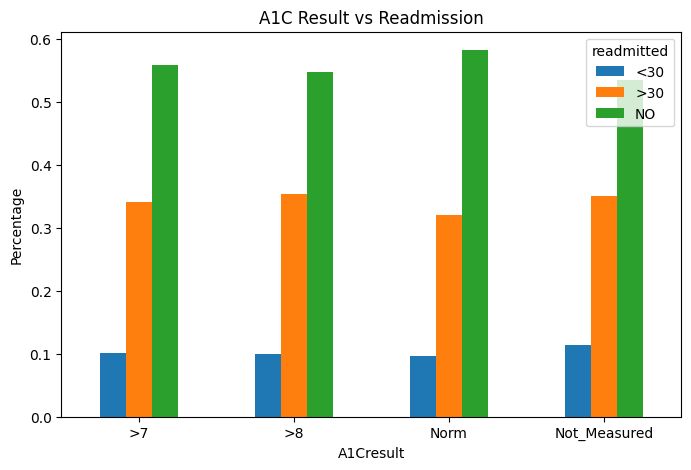

In [193]:
pd.crosstab(
    df['A1Cresult'],
    df['readmitted'],
    normalize='index'
).plot(
    kind='bar',
    figsize=(8,5)
)

plt.ylabel("Percentage")
plt.title("A1C Result vs Readmission")
plt.xticks(rotation=0)
plt.show()

MULTIVARIATE ANALYSIS

NUMERICAL FEATURE HEATMAP

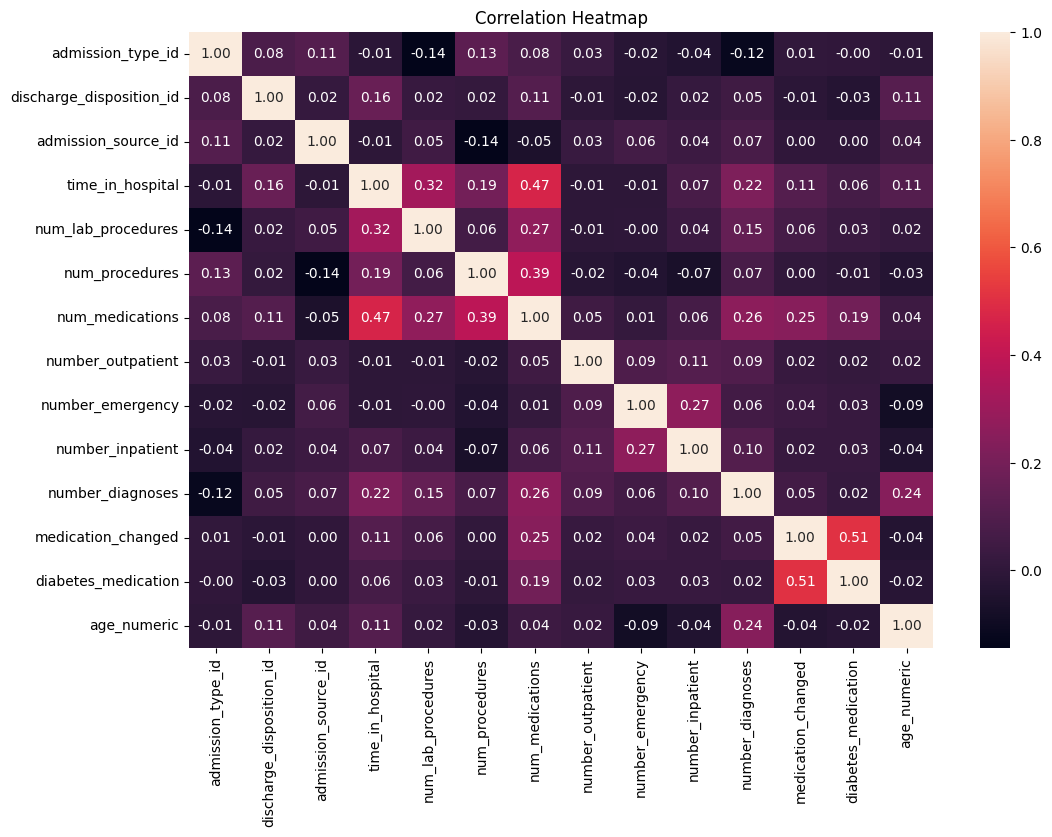

In [194]:
numeric_df = df.select_dtypes(include=np.number)
corr = numeric_df.corr()
plt.figure(figsize=(12,8))
sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
)
plt.title("Correlation Heatmap")
plt.show()

AGE VS TIME IN HOSPITAL VS READMISSION

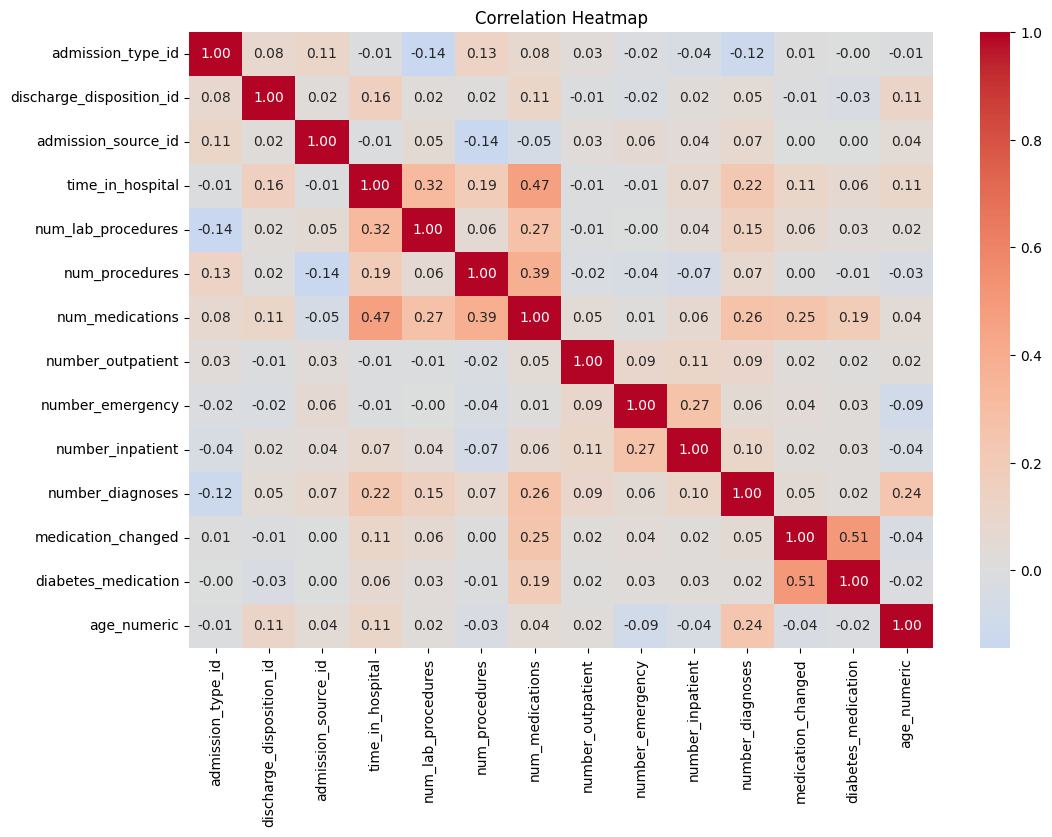

In [195]:
numeric_df = df.select_dtypes(include=np.number)
corr = numeric_df.corr()
plt.figure(figsize=(12,8))
sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)

plt.title("Correlation Heatmap")
plt.show()

AGE VS NUMBER OF MEDICATION VS READMISSION

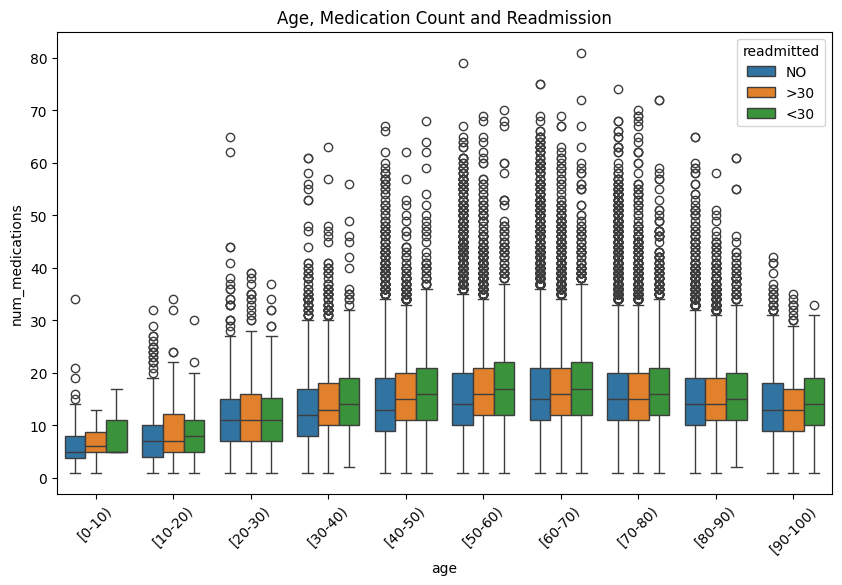

In [196]:
plt.figure(figsize=(10,6))
sns.boxplot(
    data=df,
    x='age',
    y='num_medications',
    hue='readmitted'
)
plt.title("Age, Medication Count and Readmission")
plt.xticks(rotation=45)
plt.show()

FEATURE ENGINEERING

In [197]:
df["total_previous_visit"]=df["number_outpatient"]+df["number_inpatient"]+df["number_emergency"]

In [198]:
df["total procedures"]=df["num_lab_procedures"]+df["num_procedures"]

In [199]:
df["number_of_diagnosis"]=df["diag_1"]+df["diag_2"]+df["diag_3"]

TRAIN TEST SPLIT

In [226]:
from sklearn.model_selection import train_test_split
target = 'readmitted'
X = df.drop(columns=[target])
y = df[target]
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

print( len(numeric_features))
print( len(categorical_features))

16
32


In [201]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)
print("Training shape:", X_train.shape)
print("Testing shape :", X_test.shape)

Training shape: (81412, 48)
Testing shape : (20354, 48)


In [202]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',
            StandardScaler(),
            numeric_features
        ),
        (
            'cat',
            OneHotEncoder(
                handle_unknown='ignore'
            ),
            categorical_features
        )
    ]
)

In [203]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)
print("Training processed shape:", X_train_processed.shape)
print("Testing processed shape :", X_test_processed.shape)

Training processed shape: (81412, 50886)
Testing processed shape : (20354, 50886)


PCA

In [204]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_num = scaler.fit_transform(
    X_train[numeric_features]
)
X_test_num = scaler.transform(
    X_test[numeric_features]
)


Numerical training data: (81412, 16)


In [205]:
from sklearn.decomposition import PCA
pca = PCA()
X_train_pca = pca.fit_transform(X_train_num)

In [206]:
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

Components for 90% variance: 11


/tmp/ipykernel_483/631460832.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


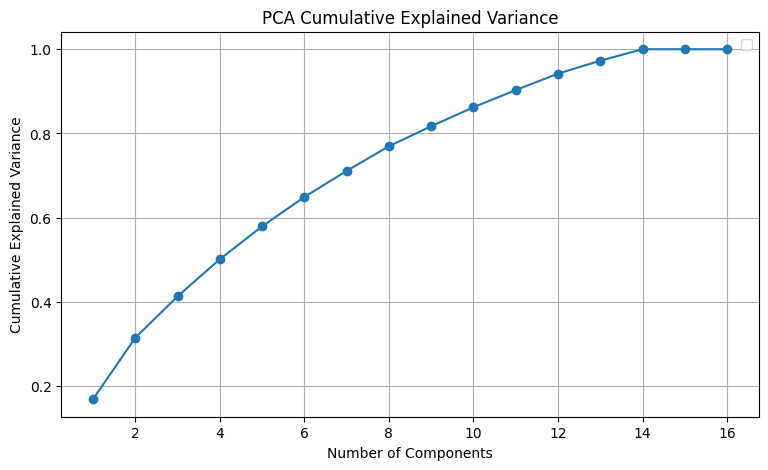

In [207]:
plt.figure(figsize=(9, 5))
plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance
)
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Cumulative Explained Variance')
plt.grid(True)
plt.show()

In [224]:
from sklearn.decomposition import PCA

pca = PCA()
X_train_pca = pca.fit_transform(X_train_num)

explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)



In [225]:
pca_reduced = PCA(n_components=n_components_90)
X_train_pca_reduced = pca_reduced.fit_transform(X_train_num)
X_test_pca_reduced = pca_reduced.transform(X_test_num)


ENCODING THE TARGET VARIABLE

In [210]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)
print("Classes:", label_encoder.classes_)

Classes: ['<30' '>30' 'NO']


In [211]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(
    n_estimators=50,
    max_depth=15,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42
)
rf_model.fit(
    X_train_processed,
    y_train_encoded
)
rf_pred = rf_model.predict(X_test_processed)
print("Random Forest completed.")

Random Forest completed.


In [212]:
from sklearn.ensemble import AdaBoostClassifier
ada_model = AdaBoostClassifier(
    n_estimators=80,
    learning_rate=0.5,
    random_state=42
)
ada_model.fit(
    X_train_processed,
    y_train_encoded
)
ada_pred = ada_model.predict(X_test_processed)
print("AdaBoost completed.")

AdaBoost completed.


In [213]:
from xgboost import XGBClassifier

In [214]:
xgb_model = XGBClassifier(
    n_estimators=50,
    max_depth=5,
    learning_rate=0.05,
    random_state=42
)
xgb_model.fit(
    X_train_processed,
    y_train_encoded
)
xgb_pred = xgb_model.predict(X_test_processed)
print("XGBoost completed.")

XGBoost completed.


In [215]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

def evaluate_model(name, y_true, y_pred):

    accuracy = accuracy_score(y_true, y_pred)

    precision = precision_score(
        y_true,
        y_pred
    )

    recall = recall_score(
        y_true,
        y_pred
    )

    f1 = f1_score(
        y_true,
        y_pred
    )


    return accuracy, precision, recall, f1

In [216]:
rf_results = evaluate_model(
    "Random Forest",
    y_test_encoded,
    rf_pred
)
ada_results = evaluate_model(
    "AdaBoost",
    y_test_encoded,
    ada_pred
)
xgb_results = evaluate_model(
    "XGBoost",
    y_test_encoded,
    xgb_pred
)


 Random Forest
Accuracy : 0.4719
Precision: 0.4213
Recall   : 0.4384
F1 Score : 0.4014

Classification Report:
              precision    recall  f1-score   support

         <30       0.17      0.44      0.25      2272
         >30       0.44      0.25      0.32      7109
          NO       0.65      0.62      0.63     10973

    accuracy                           0.47     20354
   macro avg       0.42      0.44      0.40     20354
weighted avg       0.52      0.47      0.48     20354


 AdaBoost
Accuracy : 0.5686
Precision: 0.5248
Recall   : 0.3934
F1 Score : 0.3678

Classification Report:
              precision    recall  f1-score   support

         <30       0.50      0.00      0.00      2272
         >30       0.47      0.35      0.40      7109
          NO       0.60      0.83      0.70     10973

    accuracy                           0.57     20354
   macro avg       0.52      0.39      0.37     20354
weighted avg       0.55      0.57      0.52     20354


 XGBoost
Accuracy 

In [217]:
comparison = pd.DataFrame(
    [rf_results, ada_results, xgb_results],
    columns=[
        'Accuracy',
        'Precision',
        'Recall',
        'F1 Score'
    ],
    index=[
        'Random Forest',
        'AdaBoost',
        'XGBoost'
    ]
)
comparison.round(4)

,Accuracy,Precision,Recall,F1 Score
Random Forest,0.4719,0.4213,0.4384,0.4014
AdaBoost,0.5686,0.5248,0.3934,0.3678
XGBoost,0.5842,0.4980,0.3993,0.3716


FEATURE IMPORTANCE

In [219]:
feature_names = preprocessor.get_feature_names_out()
print(len(feature_names))

50886


In [220]:
rf_importance = pd.Series(
    rf_model.feature_importances_,
    index=feature_names
).sort_values(ascending=False)

rf_importance.head(15)

,0
num__number_inpatient,0.091586
num__total_previous_visit,0.047766
num__num_medications,0.040360
num__number_diagnoses,0.035206
num__diabetes_medication,0.023930
num__admission_source_id,0.020692
num__discharge_disposition_id,0.019452
cat__diag_1_428,0.018417
cat__diabetesMed_No,0.016379
cat__diag_2_250,0.013516


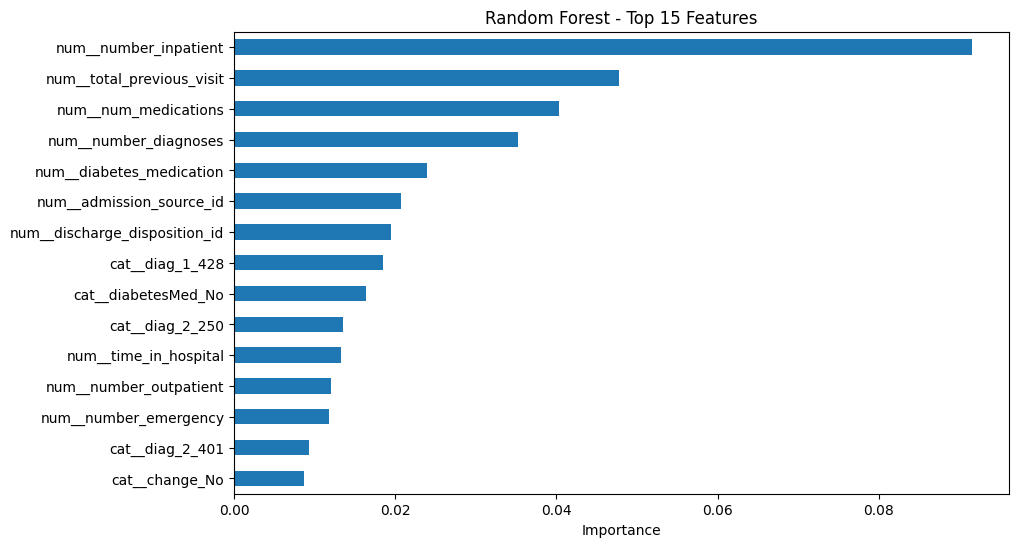

In [221]:
plt.figure(figsize=(10, 6))
rf_importance.head(15).sort_values().plot(
    kind='barh'
)
plt.xlabel("Importance")
plt.title("Random Forest - Top 15 Features")
plt.show()

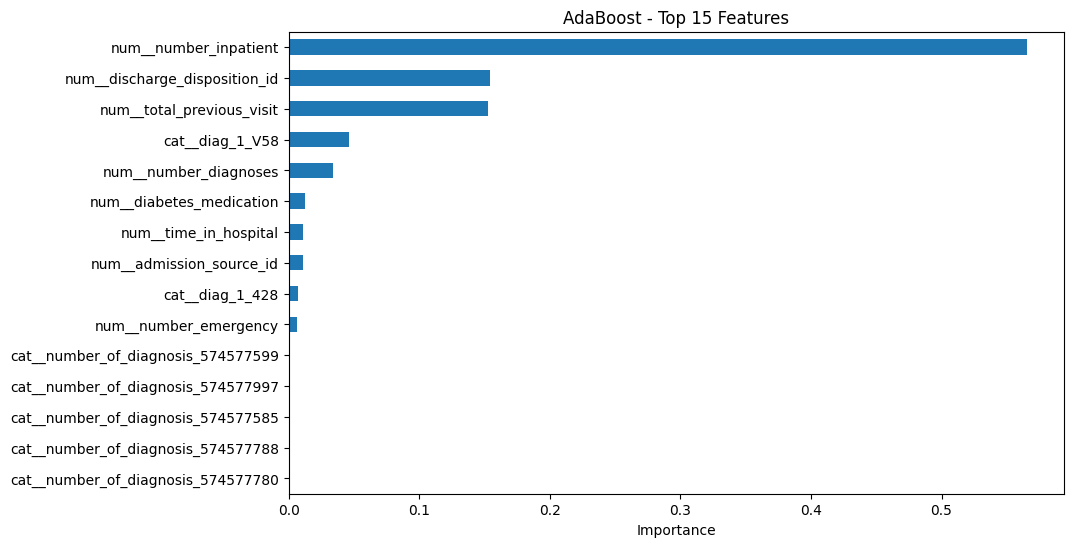

In [222]:
ada_importance = pd.Series(
    ada_model.feature_importances_,
    index=feature_names
).sort_values(ascending=False)

plt.figure(figsize=(10, 6))

ada_importance.head(15).sort_values().plot(
    kind='barh'
)
plt.xlabel("Importance")
plt.title("AdaBoost - Top 15 Features")
plt.show()

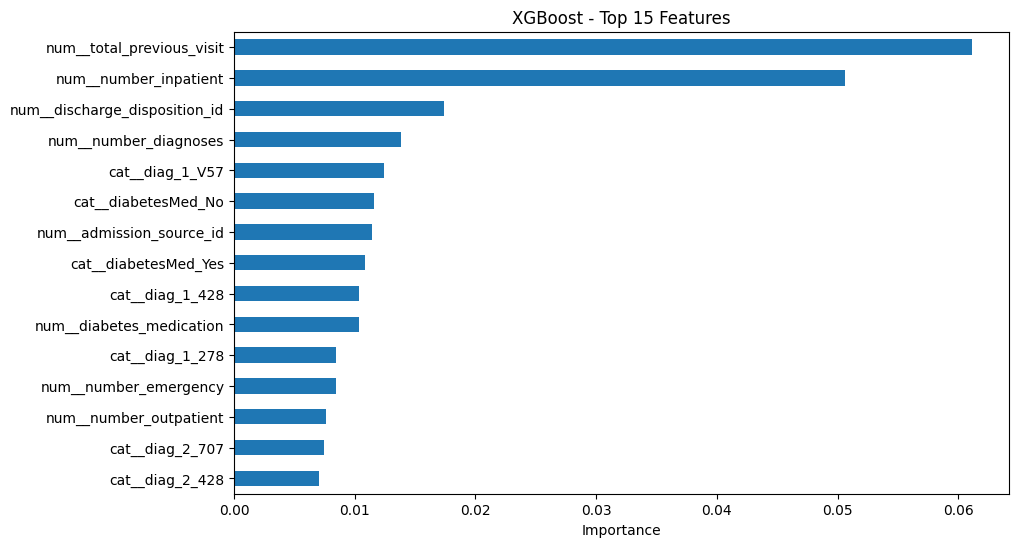

In [223]:
xgb_importance = pd.Series(
    xgb_model.feature_importances_,
    index=feature_names
).sort_values(ascending=False)

plt.figure(figsize=(10, 6))

xgb_importance.head(15).sort_values().plot(
    kind='barh'
)
plt.xlabel("Importance")
plt.title("XGBoost - Top 15 Features")
plt.show()

joblib

In [229]:
import joblib
joblib.dump(xgb_results, "best_model")

['best_model']

In [230]:
print("model saved")

model saved
